Using device: cuda
Balanced dataset: {1: 747, 0: 747}


config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]


MODEL A: BiLSTM (No Pretrained Encoder)
[BiLSTM] Epoch 1/10 | Train Loss: 0.4456 | Val Loss: 0.1959 | Val Acc: 0.9398
[BiLSTM] Epoch 2/10 | Train Loss: 0.1268 | Val Loss: 0.2151 | Val Acc: 0.9398
[BiLSTM] Epoch 3/10 | Train Loss: 0.0564 | Val Loss: 0.2308 | Val Acc: 0.9398
[BiLSTM] Epoch 4/10 | Train Loss: 0.0181 | Val Loss: 0.2840 | Val Acc: 0.9298
[BiLSTM] Epoch 5/10 | Train Loss: 0.0066 | Val Loss: 0.3318 | Val Acc: 0.9298
[BiLSTM] Epoch 6/10 | Train Loss: 0.0035 | Val Loss: 0.3516 | Val Acc: 0.9298
[BiLSTM] Epoch 7/10 | Train Loss: 0.0014 | Val Loss: 0.3626 | Val Acc: 0.9298
[BiLSTM] Epoch 8/10 | Train Loss: 0.0012 | Val Loss: 0.3766 | Val Acc: 0.9298
[BiLSTM] Epoch 9/10 | Train Loss: 0.0011 | Val Loss: 0.3812 | Val Acc: 0.9331
[BiLSTM] Epoch 10/10 | Train Loss: 0.0010 | Val Loss: 0.3838 | Val Acc: 0.9331

  BiLSTM — Final Results
  Accuracy    : 0.9331
  Precision   : 0.9338
  Recall      : 0.9331
  Specificity : 0.9533
  F1-score    : 0.9331
  AUC         : 0.9733

             

pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

[DeBERTa-BiLSTM] Epoch 1/10 | Train Loss: 0.4144 | Val Loss: 0.3333 | Val Acc: 0.8595
[DeBERTa-BiLSTM] Epoch 2/10 | Train Loss: 0.2961 | Val Loss: 0.2840 | Val Acc: 0.8896
[DeBERTa-BiLSTM] Epoch 3/10 | Train Loss: 0.2593 | Val Loss: 0.2867 | Val Acc: 0.8930
[DeBERTa-BiLSTM] Epoch 4/10 | Train Loss: 0.2788 | Val Loss: 0.2351 | Val Acc: 0.9097
[DeBERTa-BiLSTM] Epoch 5/10 | Train Loss: 0.2402 | Val Loss: 0.2320 | Val Acc: 0.9097
[DeBERTa-BiLSTM] Epoch 6/10 | Train Loss: 0.2247 | Val Loss: 0.2357 | Val Acc: 0.9130
[DeBERTa-BiLSTM] Epoch 7/10 | Train Loss: 0.2022 | Val Loss: 0.2356 | Val Acc: 0.9164
[DeBERTa-BiLSTM] Epoch 8/10 | Train Loss: 0.2196 | Val Loss: 0.2217 | Val Acc: 0.9164
[DeBERTa-BiLSTM] Epoch 9/10 | Train Loss: 0.2083 | Val Loss: 0.2189 | Val Acc: 0.9164
[DeBERTa-BiLSTM] Epoch 10/10 | Train Loss: 0.2074 | Val Loss: 0.2241 | Val Acc: 0.9164

  DeBERTa-BiLSTM — Final Results
  Accuracy    : 0.9164
  Precision   : 0.9166
  Recall      : 0.9164
  Specificity : 0.9067
  F1-score   

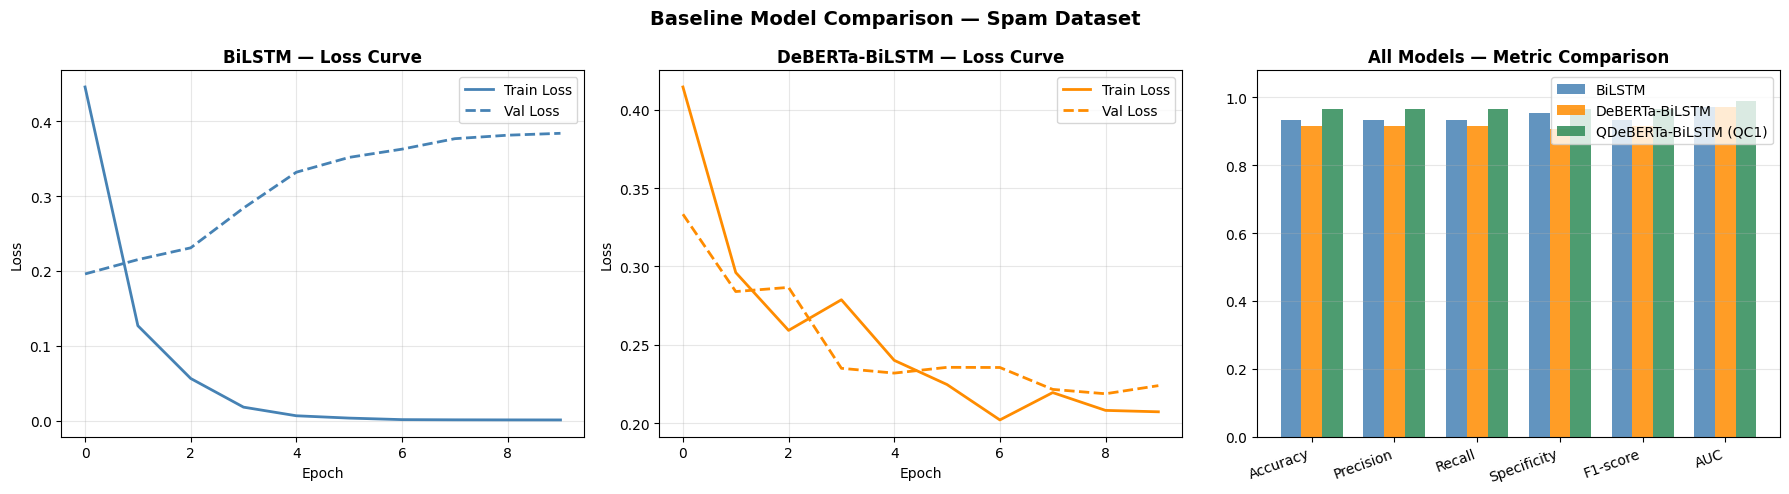


Done. Plot saved as baseline_comparison.png


In [1]:
# ==============================
# 1. Imports
# ==============================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, RandomSampler, SequentialSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score
)
from sklearn.preprocessing import LabelEncoder
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from torch.optim import AdamW
import re
import nltk
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
nltk.download('stopwords', quiet=True)

# ✅ FIX CUDA LSTM ERROR
torch.backends.cudnn.enabled = False
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# ==============================
# 2. Config
# ==============================
MAX_LEN    = 128
BATCH_SIZE = 32
EPOCHS     = 10
LR         = 1e-3           # used for BiLSTM and frozen-encoder DeBERTa-BiLSTM
HIDDEN_DIM = 128
VOCAB_SIZE  = 128100
EMBED_DIM   = 128
MODEL_NAME  = "microsoft/deberta-v3-base"

# ==============================
# 3. Load & Preprocess Data
# ==============================
df = pd.read_csv("/kaggle/input/datasets/najninsultanashirin/spam-dataset-qtl/spamdata_v2 (1).csv")
df = df.dropna(subset=['text', 'label'])

stop_words = set(stopwords.words('english'))

def clean(text):
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = text.lower()
    words = [w for w in text.split() if w not in stop_words]
    return " ".join(words)

df['text'] = df['text'].apply(clean)

le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])

# Balance classes
majority = df['label'].value_counts().idxmax()
minority = df['label'].value_counts().idxmin()
df_maj = df[df['label'] == majority].sample(len(df[df['label'] == minority]), random_state=42)
df = pd.concat([df_maj, df[df['label'] == minority]]).sample(frac=1, random_state=42).reset_index(drop=True)
print(f"Balanced dataset: {df['label'].value_counts().to_dict()}")

# ==============================
# 4. Split
# ==============================
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['text'], df['label'], test_size=0.2, stratify=df['label'], random_state=42
)

# ==============================
# 5. Tokenization
# ==============================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def encode(texts):
    return tokenizer(
        texts.tolist(),
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="pt"
    )

train_enc = encode(train_texts)
val_enc   = encode(val_texts)

def make_loader(enc, labels, sampler_cls):
    dataset = TensorDataset(
        enc['input_ids'],
        enc['attention_mask'],
        torch.tensor(labels.values, dtype=torch.long)
    )
    return DataLoader(dataset, sampler=sampler_cls(dataset), batch_size=BATCH_SIZE)

train_loader = make_loader(train_enc, train_labels, RandomSampler)
val_loader   = make_loader(val_enc,   val_labels,   SequentialSampler)

# ==============================
# 6. Metrics Helper
# ==============================
def compute_all_metrics(all_labels, all_preds, all_probs, name):
    # Guard against any remaining NaN
    all_probs = np.nan_to_num(np.array(all_probs), nan=0.5)

    acc  = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    rec  = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    spec = recall_score(all_labels, all_preds, pos_label=0, average='binary', zero_division=0)
    f1   = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    auc  = roc_auc_score(all_labels, all_probs)

    print(f"\n{'='*55}")
    print(f"  {name} — Final Results")
    print(f"{'='*55}")
    print(f"  Accuracy    : {acc:.4f}")
    print(f"  Precision   : {prec:.4f}")
    print(f"  Recall      : {rec:.4f}")
    print(f"  Specificity : {spec:.4f}")
    print(f"  F1-score    : {f1:.4f}")
    print(f"  AUC         : {auc:.4f}")
    print(f"\n{classification_report(all_labels, all_preds)}")
    return dict(accuracy=acc, precision=prec, recall=rec,
                specificity=spec, f1=f1, auc=auc)

# ==============================
# 7. Shared Training Loop
#    ✅ accepts custom lr so BiLSTM and DeBERTa-BiLSTM can use different rates
# ==============================
def train_and_evaluate(model, train_loader, val_loader, model_name, epochs=EPOCHS, lr=LR):
    model.to(DEVICE)

    # ✅ Only optimise parameters that require grad (frozen encoder is excluded)
    trainable = [p for p in model.parameters() if p.requires_grad]
    optimizer   = AdamW(trainable, lr=lr)
    total_steps = len(train_loader) * epochs
    scheduler   = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=0, num_training_steps=total_steps
    )
    loss_fn = nn.CrossEntropyLoss()
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        # ── Train ──
        model.train()
        t_loss, t_correct, t_total = 0, 0, 0
        for batch in train_loader:
            ids, mask, lbls = [b.to(DEVICE) for b in batch]
            optimizer.zero_grad()
            logits = model(ids, mask)
            loss   = loss_fn(logits, lbls)

            # ✅ Skip batch if loss is NaN (safety net)
            if torch.isnan(loss):
                print(f"  ⚠️  NaN loss detected — skipping batch")
                continue

            loss.backward()
            nn.utils.clip_grad_norm_(trainable, 1.0)
            optimizer.step()
            scheduler.step()
            t_loss    += loss.item()
            t_correct += (logits.argmax(1) == lbls).sum().item()
            t_total   += lbls.size(0)

        # ── Validate ──
        model.eval()
        v_loss, v_correct, v_total = 0, 0, 0
        all_preds, all_labels, all_probs = [], [], []

        with torch.no_grad():
            for batch in val_loader:
                ids, mask, lbls = [b.to(DEVICE) for b in batch]
                logits = model(ids, mask)
                loss   = loss_fn(logits, lbls)
                probs  = F.softmax(logits, dim=1)[:, 1].cpu().float().numpy()
                preds  = logits.argmax(1).cpu().numpy()

                v_loss    += loss.item() if not torch.isnan(loss) else 0
                v_correct += (logits.argmax(1) == lbls).sum().item()
                v_total   += lbls.size(0)
                all_preds.extend(preds)
                all_labels.extend(lbls.cpu().numpy())
                all_probs.extend(probs)

        avg_t = t_loss / max(len(train_loader), 1)
        avg_v = v_loss / max(len(val_loader), 1)
        v_acc = v_correct / max(v_total, 1)
        history['train_loss'].append(avg_t)
        history['val_loss'].append(avg_v)
        history['val_acc'].append(v_acc)

        print(f"[{model_name}] Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {avg_t:.4f} | Val Loss: {avg_v:.4f} | Val Acc: {v_acc:.4f}")

    metrics = compute_all_metrics(
        np.array(all_labels), np.array(all_preds), np.array(all_probs), model_name
    )
    return history, metrics

# ==============================
# 8. MODEL A — Plain BiLSTM
# ==============================
class BiLSTMOnly(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(VOCAB_SIZE, EMBED_DIM, padding_idx=0)
        self.lstm = nn.LSTM(
            input_size=EMBED_DIM,
            hidden_size=HIDDEN_DIM,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.6
        )
        self.dropout = nn.Dropout(0.6)
        self.fc      = nn.Linear(HIDDEN_DIM * 2, 2)

    def forward(self, ids, mask):
        x = self.embedding(ids).float()
        x = x * mask.unsqueeze(-1).float()
        lstm_out, _ = self.lstm(x)
        mask_exp = mask.unsqueeze(-1).float()
        pooled   = (lstm_out * mask_exp).sum(1) / mask_exp.sum(1).clamp(min=1e-9)
        return self.fc(self.dropout(pooled))

# ==============================
# 9. MODEL B — DeBERTa-BiLSTM
#    ✅ DeBERTa encoder is FROZEN — acts as fixed feature extractor
#    ✅ Only BiLSTM + FC are trained — prevents NaN from mixed precision
#    ✅ This is the correct classical ablation of QDeBERTa-BiLSTM
# ==============================
class DebertaBiLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert = AutoModel.from_pretrained(MODEL_NAME)

        # ✅ Freeze all DeBERTa parameters
        for param in self.bert.parameters():
            param.requires_grad = False

        self.lstm = nn.LSTM(
            input_size=768,
            hidden_size=HIDDEN_DIM,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )
        self.dropout = nn.Dropout(0.3)
        self.fc      = nn.Linear(HIDDEN_DIM * 2, 2)

    def forward(self, ids, mask):
        # ✅ No gradient through encoder — safe from NaN
        with torch.no_grad():
            outputs = self.bert(input_ids=ids, attention_mask=mask)

        # ✅ Explicit float32 cast — fixes mixed precision NaN
        x = outputs.last_hidden_state.detach().float()

        lstm_out, _ = self.lstm(x)
        mask_exp = mask.unsqueeze(-1).float()
        pooled   = (lstm_out * mask_exp).sum(1) / mask_exp.sum(1).clamp(min=1e-9)
        return self.fc(self.dropout(pooled))

# ==============================
# 10. Run MODEL A — BiLSTM
# ==============================
print("\n" + "="*55)
print("MODEL A: BiLSTM (No Pretrained Encoder)")
print("="*55)
bilstm_model = BiLSTMOnly()
history_a, metrics_a = train_and_evaluate(
    bilstm_model, train_loader, val_loader, "BiLSTM", lr=1e-3
)

# ==============================
# 11. Run MODEL B — DeBERTa-BiLSTM
# ==============================
print("\n" + "="*55)
print("MODEL B: DeBERTa-BiLSTM (Classical Ablation)")
print("="*55)
deberta_bilstm = DebertaBiLSTM()
history_b, metrics_b = train_and_evaluate(
    deberta_bilstm, train_loader, val_loader, "DeBERTa-BiLSTM", lr=1e-3
)

# ==============================
# 12. Comparison Table
# ==============================
print("\n" + "="*55)
print("FINAL COMPARISON TABLE")
print("="*55)

keys       = ['accuracy', 'precision', 'recall', 'specificity', 'f1', 'auc']
labels_row = ['Accuracy', 'Precision', 'Recall', 'Specificity', 'F1-score', 'AUC']

comparison = pd.DataFrame({
    'Metric'          : labels_row,
    'BiLSTM'          : [round(metrics_a[k], 4) for k in keys],
    'DeBERTa-BiLSTM'  : [round(metrics_b[k], 4) for k in keys],
    'QDeBERTa-BiLSTM' : [0.9666, 0.9664, 0.9668, 0.9668, 0.9665, 0.9886],
}).set_index('Metric')

print(comparison.to_string())

# ==============================
# 13. Plots
# ==============================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Baseline Model Comparison — Spam Dataset", fontsize=14, fontweight='bold')

axes[0].plot(history_a['train_loss'], label='Train Loss', color='steelblue', linewidth=2)
axes[0].plot(history_a['val_loss'],   label='Val Loss',   color='steelblue', linewidth=2, linestyle='--')
axes[0].set_title("BiLSTM — Loss Curve", fontweight='bold')
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history_b['train_loss'], label='Train Loss', color='darkorange', linewidth=2)
axes[1].plot(history_b['val_loss'],   label='Val Loss',   color='darkorange', linewidth=2, linestyle='--')
axes[1].set_title("DeBERTa-BiLSTM — Loss Curve", fontweight='bold')
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].legend(); axes[1].grid(alpha=0.3)

x = np.arange(len(labels_row))
w = 0.25
axes[2].bar(x - w, [metrics_a[k] for k in keys], w,
            label='BiLSTM', color='steelblue', alpha=0.85)
axes[2].bar(x,     [metrics_b[k] for k in keys], w,
            label='DeBERTa-BiLSTM', color='darkorange', alpha=0.85)
axes[2].bar(x + w, [0.9666, 0.9664, 0.9668, 0.9668, 0.9665, 0.9886], w,
            label='QDeBERTa-BiLSTM (QC1)', color='seagreen', alpha=0.85)
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels_row, rotation=20, ha='right')
axes[2].set_ylim(0, 1.08)
axes[2].set_title("All Models — Metric Comparison", fontweight='bold')
axes[2].legend(); axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("baseline_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nDone. Plot saved as baseline_comparison.png")

# MPQA

In [1]:
from datasets import load_dataset

ds = load_dataset("jxm/mpqa")

README.md:   0%|          | 0.00/650 [00:00<?, ?B/s]

data/train-00000-of-00001-a7df005a1b0788(…):   0%|          | 0.00/141k [00:00<?, ?B/s]

data/test-00000-of-00001-05fc5ca1c399669(…):   0%|          | 0.00/33.7k [00:00<?, ?B/s]

data/dev-00000-of-00001-8814a3252cc44468(…):   0%|          | 0.00/6.19k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/8603 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating dev split:   0%|          | 0/256 [00:00<?, ? examples/s]

Using device: cuda
Balanced dataset: {0: 2311, 1: 2311}

MODEL A: BiLSTM (No Pretrained Encoder)
[BiLSTM] Epoch 1/10 | Train Loss: 0.6500 | Val Loss: 0.6177 | Val Acc: 0.6476
[BiLSTM] Epoch 2/10 | Train Loss: 0.4893 | Val Loss: 0.6212 | Val Acc: 0.6800
[BiLSTM] Epoch 3/10 | Train Loss: 0.3277 | Val Loss: 0.6482 | Val Acc: 0.7070
[BiLSTM] Epoch 4/10 | Train Loss: 0.1991 | Val Loss: 0.7956 | Val Acc: 0.7200
[BiLSTM] Epoch 5/10 | Train Loss: 0.1410 | Val Loss: 0.9270 | Val Acc: 0.7124
[BiLSTM] Epoch 6/10 | Train Loss: 0.1067 | Val Loss: 1.0305 | Val Acc: 0.7308
[BiLSTM] Epoch 7/10 | Train Loss: 0.0882 | Val Loss: 1.0184 | Val Acc: 0.7362
[BiLSTM] Epoch 8/10 | Train Loss: 0.0830 | Val Loss: 1.0788 | Val Acc: 0.7330
[BiLSTM] Epoch 9/10 | Train Loss: 0.0687 | Val Loss: 1.1863 | Val Acc: 0.7308
[BiLSTM] Epoch 10/10 | Train Loss: 0.0597 | Val Loss: 1.2368 | Val Acc: 0.7319

  BiLSTM — Final Results
  Accuracy    : 0.7319
  Precision   : 0.7320
  Recall      : 0.7319
  Specificity : 0.7235
  F1

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[DeBERTa-BiLSTM] Epoch 1/10 | Train Loss: 0.6847 | Val Loss: 0.6955 | Val Acc: 0.5362
[DeBERTa-BiLSTM] Epoch 2/10 | Train Loss: 0.6839 | Val Loss: 0.6896 | Val Acc: 0.5470
[DeBERTa-BiLSTM] Epoch 3/10 | Train Loss: 0.6790 | Val Loss: 0.6894 | Val Acc: 0.5546
[DeBERTa-BiLSTM] Epoch 4/10 | Train Loss: 0.6686 | Val Loss: 0.6942 | Val Acc: 0.5470
[DeBERTa-BiLSTM] Epoch 5/10 | Train Loss: 0.6635 | Val Loss: 0.6844 | Val Acc: 0.5438
[DeBERTa-BiLSTM] Epoch 6/10 | Train Loss: 0.6600 | Val Loss: 0.6894 | Val Acc: 0.5427
[DeBERTa-BiLSTM] Epoch 7/10 | Train Loss: 0.6524 | Val Loss: 0.6769 | Val Acc: 0.5622
[DeBERTa-BiLSTM] Epoch 8/10 | Train Loss: 0.6515 | Val Loss: 0.6980 | Val Acc: 0.5514
[DeBERTa-BiLSTM] Epoch 9/10 | Train Loss: 0.6464 | Val Loss: 0.6718 | Val Acc: 0.5719
[DeBERTa-BiLSTM] Epoch 10/10 | Train Loss: 0.6489 | Val Loss: 0.6799 | Val Acc: 0.5589

  DeBERTa-BiLSTM — Final Results
  Accuracy    : 0.5589
  Precision   : 0.6042
  Recall      : 0.5589
  Specificity : 0.2311
  F1-score   

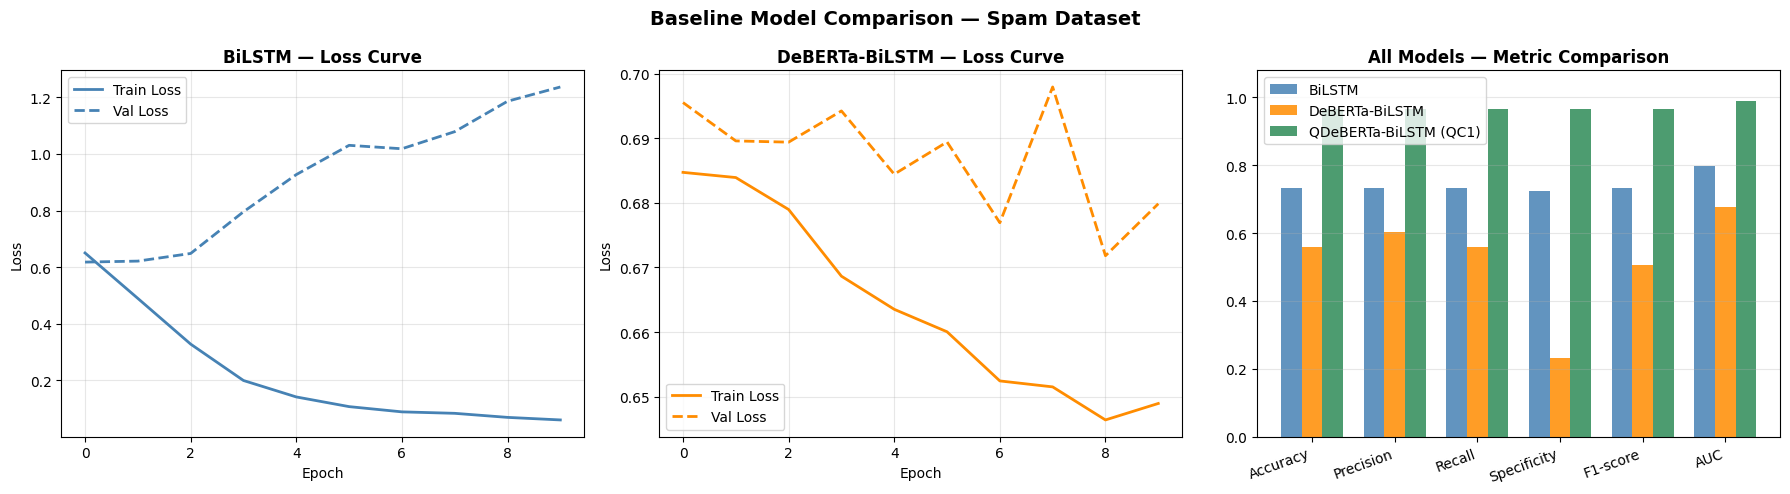


Done. Plot saved as baseline_comparison.png


In [7]:
# ==============================
# 1. Imports
# ==============================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, RandomSampler, SequentialSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score
)
from sklearn.preprocessing import LabelEncoder
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from torch.optim import AdamW
import re
import nltk
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
nltk.download('stopwords', quiet=True)

# ✅ FIX CUDA LSTM ERROR
torch.backends.cudnn.enabled = False
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# ==============================
# 2. Config
# ==============================
MAX_LEN    = 128
BATCH_SIZE = 32
EPOCHS     = 10
LR         = 1e-3           # used for BiLSTM and frozen-encoder DeBERTa-BiLSTM
HIDDEN_DIM = 128
VOCAB_SIZE  = 128100
EMBED_DIM   = 128
MODEL_NAME  = "microsoft/deberta-v3-base"

# ==============================
# 3. Load & Preprocess Data
# ==============================
ds = load_dataset("jxm/mpqa")
# Convert train split to pandas (MPQA already split)
df = ds["train"].to_pandas()
df = df.dropna(subset=['sentence', 'label'])

stop_words = set(stopwords.words('english'))

def clean(text):
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = text.lower()
    words = [w for w in text.split() if w not in stop_words]
    return " ".join(words)

df['text'] = df['sentence'].apply(clean)

le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])

# Balance classes
majority = df['label'].value_counts().idxmax()
minority = df['label'].value_counts().idxmin()
df_maj = df[df['label'] == majority].sample(len(df[df['label'] == minority]), random_state=42)
df = pd.concat([df_maj, df[df['label'] == minority]]).sample(frac=1, random_state=42).reset_index(drop=True)
print(f"Balanced dataset: {df['label'].value_counts().to_dict()}")

# ==============================
# 4. Split
# ==============================
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['text'], df['label'], test_size=0.2, stratify=df['label'], random_state=42
)

# ==============================
# 5. Tokenization
# ==============================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def encode(texts):
    return tokenizer(
        texts.tolist(),
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="pt"
    )

train_enc = encode(train_texts)
val_enc   = encode(val_texts)

def make_loader(enc, labels, sampler_cls):
    dataset = TensorDataset(
        enc['input_ids'],
        enc['attention_mask'],
        torch.tensor(labels.values, dtype=torch.long)
    )
    return DataLoader(dataset, sampler=sampler_cls(dataset), batch_size=BATCH_SIZE)

train_loader = make_loader(train_enc, train_labels, RandomSampler)
val_loader   = make_loader(val_enc,   val_labels,   SequentialSampler)

# ==============================
# 6. Metrics Helper
# ==============================
def compute_all_metrics(all_labels, all_preds, all_probs, name):
    # Guard against any remaining NaN
    all_probs = np.nan_to_num(np.array(all_probs), nan=0.5)

    acc  = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    rec  = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    spec = recall_score(all_labels, all_preds, pos_label=0, average='binary', zero_division=0)
    f1   = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    auc  = roc_auc_score(all_labels, all_probs)

    print(f"\n{'='*55}")
    print(f"  {name} — Final Results")
    print(f"{'='*55}")
    print(f"  Accuracy    : {acc:.4f}")
    print(f"  Precision   : {prec:.4f}")
    print(f"  Recall      : {rec:.4f}")
    print(f"  Specificity : {spec:.4f}")
    print(f"  F1-score    : {f1:.4f}")
    print(f"  AUC         : {auc:.4f}")
    print(f"\n{classification_report(all_labels, all_preds)}")
    return dict(accuracy=acc, precision=prec, recall=rec,
                specificity=spec, f1=f1, auc=auc)

# ==============================
# 7. Shared Training Loop
#    ✅ accepts custom lr so BiLSTM and DeBERTa-BiLSTM can use different rates
# ==============================
def train_and_evaluate(model, train_loader, val_loader, model_name, epochs=EPOCHS, lr=LR):
    model.to(DEVICE)

    # ✅ Only optimise parameters that require grad (frozen encoder is excluded)
    trainable = [p for p in model.parameters() if p.requires_grad]
    optimizer   = AdamW(trainable, lr=lr)
    total_steps = len(train_loader) * epochs
    scheduler   = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=0, num_training_steps=total_steps
    )
    loss_fn = nn.CrossEntropyLoss()
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        # ── Train ──
        model.train()
        t_loss, t_correct, t_total = 0, 0, 0
        for batch in train_loader:
            ids, mask, lbls = [b.to(DEVICE) for b in batch]
            optimizer.zero_grad()
            logits = model(ids, mask)
            loss   = loss_fn(logits, lbls)

            # ✅ Skip batch if loss is NaN (safety net)
            if torch.isnan(loss):
                print(f"  ⚠️  NaN loss detected — skipping batch")
                continue

            loss.backward()
            nn.utils.clip_grad_norm_(trainable, 1.0)
            optimizer.step()
            scheduler.step()
            t_loss    += loss.item()
            t_correct += (logits.argmax(1) == lbls).sum().item()
            t_total   += lbls.size(0)

        # ── Validate ──
        model.eval()
        v_loss, v_correct, v_total = 0, 0, 0
        all_preds, all_labels, all_probs = [], [], []

        with torch.no_grad():
            for batch in val_loader:
                ids, mask, lbls = [b.to(DEVICE) for b in batch]
                logits = model(ids, mask)
                loss   = loss_fn(logits, lbls)
                probs  = F.softmax(logits, dim=1)[:, 1].cpu().float().numpy()
                preds  = logits.argmax(1).cpu().numpy()

                v_loss    += loss.item() if not torch.isnan(loss) else 0
                v_correct += (logits.argmax(1) == lbls).sum().item()
                v_total   += lbls.size(0)
                all_preds.extend(preds)
                all_labels.extend(lbls.cpu().numpy())
                all_probs.extend(probs)

        avg_t = t_loss / max(len(train_loader), 1)
        avg_v = v_loss / max(len(val_loader), 1)
        v_acc = v_correct / max(v_total, 1)
        history['train_loss'].append(avg_t)
        history['val_loss'].append(avg_v)
        history['val_acc'].append(v_acc)

        print(f"[{model_name}] Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {avg_t:.4f} | Val Loss: {avg_v:.4f} | Val Acc: {v_acc:.4f}")

    metrics = compute_all_metrics(
        np.array(all_labels), np.array(all_preds), np.array(all_probs), model_name
    )
    return history, metrics

# ==============================
# 8. MODEL A — Plain BiLSTM
# ==============================
class BiLSTMOnly(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(VOCAB_SIZE, EMBED_DIM, padding_idx=0)
        self.lstm = nn.LSTM(
            input_size=EMBED_DIM,
            hidden_size=HIDDEN_DIM,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )
        self.dropout = nn.Dropout(0.3)
        self.fc      = nn.Linear(HIDDEN_DIM * 2, 2)

    def forward(self, ids, mask):
        x = self.embedding(ids).float()
        x = x * mask.unsqueeze(-1).float()
        lstm_out, _ = self.lstm(x)
        mask_exp = mask.unsqueeze(-1).float()
        pooled   = (lstm_out * mask_exp).sum(1) / mask_exp.sum(1).clamp(min=1e-9)
        return self.fc(self.dropout(pooled))

# ==============================
# 9. MODEL B — DeBERTa-BiLSTM
#    ✅ DeBERTa encoder is FROZEN — acts as fixed feature extractor
#    ✅ Only BiLSTM + FC are trained — prevents NaN from mixed precision
#    ✅ This is the correct classical ablation of QDeBERTa-BiLSTM
# ==============================
class DebertaBiLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert = AutoModel.from_pretrained(MODEL_NAME)

        # ✅ Freeze all DeBERTa parameters
        for param in self.bert.parameters():
            param.requires_grad = False

        self.lstm = nn.LSTM(
            input_size=768,
            hidden_size=HIDDEN_DIM,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )
        self.dropout = nn.Dropout(0.3)
        self.fc      = nn.Linear(HIDDEN_DIM * 2, 2)

    def forward(self, ids, mask):
        # ✅ No gradient through encoder — safe from NaN
        with torch.no_grad():
            outputs = self.bert(input_ids=ids, attention_mask=mask)

        # ✅ Explicit float32 cast — fixes mixed precision NaN
        x = outputs.last_hidden_state.detach().float()

        lstm_out, _ = self.lstm(x)
        mask_exp = mask.unsqueeze(-1).float()
        pooled   = (lstm_out * mask_exp).sum(1) / mask_exp.sum(1).clamp(min=1e-9)
        return self.fc(self.dropout(pooled))

# ==============================
# 10. Run MODEL A — BiLSTM
# ==============================
print("\n" + "="*55)
print("MODEL A: BiLSTM (No Pretrained Encoder)")
print("="*55)
bilstm_model = BiLSTMOnly()
history_a, metrics_a = train_and_evaluate(
    bilstm_model, train_loader, val_loader, "BiLSTM", lr=1e-3
)

# ==============================
# 11. Run MODEL B — DeBERTa-BiLSTM
# ==============================
print("\n" + "="*55)
print("MODEL B: DeBERTa-BiLSTM (Classical Ablation)")
print("="*55)
deberta_bilstm = DebertaBiLSTM()
history_b, metrics_b = train_and_evaluate(
    deberta_bilstm, train_loader, val_loader, "DeBERTa-BiLSTM", lr=1e-3
)

# ==============================
# 12. Comparison Table
# ==============================
print("\n" + "="*55)
print("FINAL COMPARISON TABLE")
print("="*55)

keys       = ['accuracy', 'precision', 'recall', 'specificity', 'f1', 'auc']
labels_row = ['Accuracy', 'Precision', 'Recall', 'Specificity', 'F1-score', 'AUC']

comparison = pd.DataFrame({
    'Metric'          : labels_row,
    'BiLSTM'          : [round(metrics_a[k], 4) for k in keys],
    'DeBERTa-BiLSTM'  : [round(metrics_b[k], 4) for k in keys],
    'QDeBERTa-BiLSTM' : [0.9666, 0.9664, 0.9668, 0.9668, 0.9665, 0.9886],
}).set_index('Metric')

print(comparison.to_string())

# ==============================
# 13. Plots
# ==============================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Baseline Model Comparison — Spam Dataset", fontsize=14, fontweight='bold')

axes[0].plot(history_a['train_loss'], label='Train Loss', color='steelblue', linewidth=2)
axes[0].plot(history_a['val_loss'],   label='Val Loss',   color='steelblue', linewidth=2, linestyle='--')
axes[0].set_title("BiLSTM — Loss Curve", fontweight='bold')
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history_b['train_loss'], label='Train Loss', color='darkorange', linewidth=2)
axes[1].plot(history_b['val_loss'],   label='Val Loss',   color='darkorange', linewidth=2, linestyle='--')
axes[1].set_title("DeBERTa-BiLSTM — Loss Curve", fontweight='bold')
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].legend(); axes[1].grid(alpha=0.3)

x = np.arange(len(labels_row))
w = 0.25
axes[2].bar(x - w, [metrics_a[k] for k in keys], w,
            label='BiLSTM', color='steelblue', alpha=0.85)
axes[2].bar(x,     [metrics_b[k] for k in keys], w,
            label='DeBERTa-BiLSTM', color='darkorange', alpha=0.85)
axes[2].bar(x + w, [0.9666, 0.9664, 0.9668, 0.9668, 0.9665, 0.9886], w,
            label='QDeBERTa-BiLSTM (QC1)', color='seagreen', alpha=0.85)
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels_row, rotation=20, ha='right')
axes[2].set_ylim(0, 1.08)
axes[2].set_title("All Models — Metric Comparison", fontweight='bold')
axes[2].legend(); axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("baseline_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nDone. Plot saved as baseline_comparison.png")

In [3]:
# ==============================
# 1. Imports
# ==============================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, RandomSampler, SequentialSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score
)
from sklearn.preprocessing import LabelEncoder
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from torch.optim import AdamW
import re
import nltk
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
import warnings

from datasets import load_dataset

warnings.filterwarnings('ignore')
nltk.download('stopwords', quiet=True)

# ✅ FIX CUDA LSTM ERROR
torch.backends.cudnn.enabled = False
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# ==============================
# 2. Config
# ==============================
MAX_LEN    = 128
BATCH_SIZE = 32
EPOCHS     = 10
LR_BILSTM  = 1e-3
LR_BERT    = 2e-5
HIDDEN_DIM = 128
EMBED_DIM  = 128
MODEL_NAME = "microsoft/deberta-v3-base"

# ==============================
# 3. Load & Preprocess Data
# ==============================
ds = load_dataset("jxm/mpqa")
df = ds["train"].to_pandas()
df = df.dropna(subset=['sentence', 'label'])

stop_words = set(stopwords.words('english'))

def clean(text):
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = text.lower()
    words = [w for w in text.split() if w not in stop_words]
    return " ".join(words)

df['text'] = df['sentence'].apply(clean)
le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])

# Balance classes
majority = df['label'].value_counts().idxmax()
minority = df['label'].value_counts().idxmin()
df_maj = df[df['label'] == majority].sample(len(df[df['label'] == minority]), random_state=42)
df = pd.concat([df_maj, df[df['label'] == minority]]).sample(frac=1, random_state=42).reset_index(drop=True)
print(f"Balanced dataset: {df['label'].value_counts().to_dict()}")

# ==============================
# 4. Split
# ==============================
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['text'], df['label'], test_size=0.2, stratify=df['label'], random_state=42
)

# ==============================
# 5. Tokenization
# ==============================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def encode(texts):
    return tokenizer(
        texts.tolist(),
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="pt"
    )

train_enc = encode(train_texts)
val_enc   = encode(val_texts)

def make_loader(enc, labels, sampler_cls):
    dataset = TensorDataset(
        enc['input_ids'],
        enc['attention_mask'],
        torch.tensor(labels.values, dtype=torch.long)
    )
    return DataLoader(dataset, sampler=sampler_cls(dataset), batch_size=BATCH_SIZE)

train_loader = make_loader(train_enc, train_labels, RandomSampler)
val_loader   = make_loader(val_enc,   val_labels,   SequentialSampler)

# ==============================
# 6. Metrics Helper
# ==============================
def compute_all_metrics(all_labels, all_preds, all_probs, name):
    all_probs = np.nan_to_num(np.array(all_probs), nan=0.5)

    acc  = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    rec  = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    spec = recall_score(all_labels, all_preds, pos_label=0, average='binary', zero_division=0)
    f1   = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    auc  = roc_auc_score(all_labels, all_probs)

    print(f"\n{'='*55}")
    print(f"  {name} — Final Results")
    print(f"{'='*55}")
    print(f"  Accuracy    : {acc:.4f}")
    print(f"  Precision   : {prec:.4f}")
    print(f"  Recall      : {rec:.4f}")
    print(f"  Specificity : {spec:.4f}")
    print(f"  F1-score    : {f1:.4f}")
    print(f"  AUC         : {auc:.4f}")
    print(f"\n{classification_report(all_labels, all_preds)}")
    return dict(accuracy=acc, precision=prec, recall=rec,
                specificity=spec, f1=f1, auc=auc)

# ==============================
# 7. Training Loop
# ==============================
def train_and_evaluate(model, train_loader, val_loader, model_name, epochs=EPOCHS, lr_bert=None, lr_other=None):
    model.to(DEVICE)

    # Layer-specific learning rate
    if lr_bert is not None and lr_other is not None:
        optimizer = AdamW([
            {'params': model.bert.parameters(), 'lr': lr_bert},
            {'params': [p for n, p in model.named_parameters() if 'bert' not in n], 'lr': lr_other}
        ])
    else:
        optimizer = AdamW(model.parameters(), lr=LR_BILSTM)

    total_steps = len(train_loader) * epochs
    scheduler   = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=0, num_training_steps=total_steps
    )
    loss_fn = nn.CrossEntropyLoss()
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        # ── Train ──
        model.train()
        t_loss, t_correct, t_total = 0, 0, 0
        for batch in train_loader:
            ids, mask, lbls = [b.to(DEVICE) for b in batch]
            optimizer.zero_grad()
            logits = model(ids, mask)
            loss   = loss_fn(logits, lbls)
            if torch.isnan(loss):
                print(f"  ⚠️  NaN loss detected — skipping batch")
                continue
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            t_loss    += loss.item()
            t_correct += (logits.argmax(1) == lbls).sum().item()
            t_total   += lbls.size(0)

        # ── Validate ──
        model.eval()
        v_loss, v_correct, v_total = 0, 0, 0
        all_preds, all_labels, all_probs = [], [], []
        with torch.no_grad():
            for batch in val_loader:
                ids, mask, lbls = [b.to(DEVICE) for b in batch]
                logits = model(ids, mask)
                loss   = loss_fn(logits, lbls)
                probs  = F.softmax(logits, dim=1)[:, 1].cpu().float().numpy()
                preds  = logits.argmax(1).cpu().numpy()

                v_loss    += loss.item() if not torch.isnan(loss) else 0
                v_correct += (logits.argmax(1) == lbls).sum().item()
                v_total   += lbls.size(0)
                all_preds.extend(preds)
                all_labels.extend(lbls.cpu().numpy())
                all_probs.extend(probs)

        avg_t = t_loss / max(len(train_loader), 1)
        avg_v = v_loss / max(len(val_loader), 1)
        v_acc = v_correct / max(v_total, 1)
        history['train_loss'].append(avg_t)
        history['val_loss'].append(avg_v)
        history['val_acc'].append(v_acc)

        print(f"[{model_name}] Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {avg_t:.4f} | Val Loss: {avg_v:.4f} | Val Acc: {v_acc:.4f}")

    metrics = compute_all_metrics(np.array(all_labels), np.array(all_preds), np.array(all_probs), model_name)
    return history, metrics

# ==============================
# 8. MODEL A — Plain BiLSTM
# ==============================
VOCAB_SIZE = tokenizer.vocab_size

class BiLSTMOnly(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(VOCAB_SIZE, EMBED_DIM, padding_idx=0)
        self.lstm = nn.LSTM(
            input_size=EMBED_DIM,
            hidden_size=HIDDEN_DIM,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )
        self.dropout = nn.Dropout(0.3)
        self.fc      = nn.Linear(HIDDEN_DIM * 2, 2)

    def forward(self, ids, mask):
        x = self.embedding(ids).float()
        x = x * mask.unsqueeze(-1).float()
        lstm_out, _ = self.lstm(x)
        mask_exp   = mask.unsqueeze(-1).float()
        pooled     = (lstm_out * mask_exp).sum(1) / mask_exp.sum(1).clamp(min=1e-9)
        return self.fc(self.dropout(pooled))



# ==============================
# 10. Run BiLSTM
# ==============================
print("\n" + "="*55)
print("MODEL A: BiLSTM (No Pretrained Encoder)")
print("="*55)
bilstm_model = BiLSTMOnly()
history_a, metrics_a = train_and_evaluate(bilstm_model, train_loader, val_loader, "BiLSTM", lr_bert=None, lr_other=LR_BILSTM)

# ==============================
# 12. Comparison Table
# ==============================
print("\n" + "="*55)
print("FINAL COMPARISON TABLE")
print("="*55)

keys       = ['accuracy', 'precision', 'recall', 'specificity', 'f1', 'auc']
labels_row = ['Accuracy', 'Precision', 'Recall', 'Specificity', 'F1-score', 'AUC']

comparison = pd.DataFrame({
    'Metric'          : labels_row,
    'BiLSTM'          : [round(metrics_a[k], 4) for k in keys],
    'QDeBERTa-BiLSTM' : [0.9666, 0.9664, 0.9668, 0.9668, 0.9665, 0.9886],
}).set_index('Metric')

print(comparison.to_string())

Using device: cuda
Balanced dataset: {0: 2311, 1: 2311}

MODEL A: BiLSTM (No Pretrained Encoder)
[BiLSTM] Epoch 1/10 | Train Loss: 0.6483 | Val Loss: 0.6142 | Val Acc: 0.6303
[BiLSTM] Epoch 2/10 | Train Loss: 0.4961 | Val Loss: 0.5694 | Val Acc: 0.6941
[BiLSTM] Epoch 3/10 | Train Loss: 0.3465 | Val Loss: 0.6437 | Val Acc: 0.7178
[BiLSTM] Epoch 4/10 | Train Loss: 0.2137 | Val Loss: 0.7834 | Val Acc: 0.7157
[BiLSTM] Epoch 5/10 | Train Loss: 0.1566 | Val Loss: 0.8990 | Val Acc: 0.7222
[BiLSTM] Epoch 6/10 | Train Loss: 0.1145 | Val Loss: 0.9927 | Val Acc: 0.7146
[BiLSTM] Epoch 7/10 | Train Loss: 0.0986 | Val Loss: 1.0085 | Val Acc: 0.7265
[BiLSTM] Epoch 8/10 | Train Loss: 0.0838 | Val Loss: 1.1316 | Val Acc: 0.7222
[BiLSTM] Epoch 9/10 | Train Loss: 0.0720 | Val Loss: 1.1695 | Val Acc: 0.7243
[BiLSTM] Epoch 10/10 | Train Loss: 0.0622 | Val Loss: 1.2356 | Val Acc: 0.7243

  BiLSTM — Final Results
  Accuracy    : 0.7243
  Precision   : 0.7250
  Recall      : 0.7243
  Specificity : 0.7516
  F1

# MR

In [1]:
from datasets import load_dataset

ds = load_dataset("mattymchen/mr")

README.md:   0%|          | 0.00/688 [00:00<?, ?B/s]

data/test-00000-of-00001-1ad570418120a67(…):   0%|          | 0.00/884k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/10662 [00:00<?, ? examples/s]

Using device: cuda
MR dataset loaded: (10662, 2)
                                                text  label
0  with its dogged hollywood naturalism and the i...      0
1  . . . has its moments , but ultimately , its c...      0
2  leigh 's film is full of memorable performance...      1
3  the code talkers deserved better than a hollow...      0
4     i have to admit that i am baffled by jason x .      0
Label distribution:
label
0    5331
1    5331
Name: count, dtype: int64
Before balancing: {0: 5331, 1: 5331}
Balanced dataset: {0: 5331, 1: 5331}
Train: 8529 | Val: 2133

MODEL A: BiLSTM — MR
[BiLSTM] Epoch 1/10 | Train Loss: 0.6597 | Val Loss: 0.6104 | Val Acc: 0.6728
[BiLSTM] Epoch 2/10 | Train Loss: 0.4970 | Val Loss: 0.6041 | Val Acc: 0.7089
[BiLSTM] Epoch 3/10 | Train Loss: 0.2882 | Val Loss: 0.6940 | Val Acc: 0.7135
[BiLSTM] Epoch 4/10 | Train Loss: 0.1235 | Val Loss: 1.0115 | Val Acc: 0.7206
[BiLSTM] Epoch 5/10 | Train Loss: 0.0491 | Val Loss: 1.4213 | Val Acc: 0.7159
[BiLSTM] 

pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
mask_predictions.classifier.weight      | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

[DeBERTa-BiLSTM] Epoch 1/10 | Train Loss: 0.6964 | Val Loss: 0.6918 | Val Acc: 0.5288
[DeBERTa-BiLSTM] Epoch 2/10 | Train Loss: 0.6941 | Val Loss: 0.6914 | Val Acc: 0.5349
[DeBERTa-BiLSTM] Epoch 3/10 | Train Loss: 0.6924 | Val Loss: 0.6893 | Val Acc: 0.5368
[DeBERTa-BiLSTM] Epoch 4/10 | Train Loss: 0.6913 | Val Loss: 0.6895 | Val Acc: 0.5410
[DeBERTa-BiLSTM] Epoch 5/10 | Train Loss: 0.6904 | Val Loss: 0.6884 | Val Acc: 0.5373
[DeBERTa-BiLSTM] Epoch 6/10 | Train Loss: 0.6830 | Val Loss: 0.6866 | Val Acc: 0.5677
[DeBERTa-BiLSTM] Epoch 7/10 | Train Loss: 0.6762 | Val Loss: 0.6857 | Val Acc: 0.5743
[DeBERTa-BiLSTM] Epoch 8/10 | Train Loss: 0.6729 | Val Loss: 0.6697 | Val Acc: 0.5823
[DeBERTa-BiLSTM] Epoch 9/10 | Train Loss: 0.6714 | Val Loss: 0.6728 | Val Acc: 0.5776
[DeBERTa-BiLSTM] Epoch 10/10 | Train Loss: 0.6698 | Val Loss: 0.6699 | Val Acc: 0.5799

  DeBERTa-BiLSTM — Final Results (MR)
  Accuracy    : 0.5799
  Precision   : 0.5822
  Recall      : 0.5799
  Specificity : 0.4977
  F1-sco

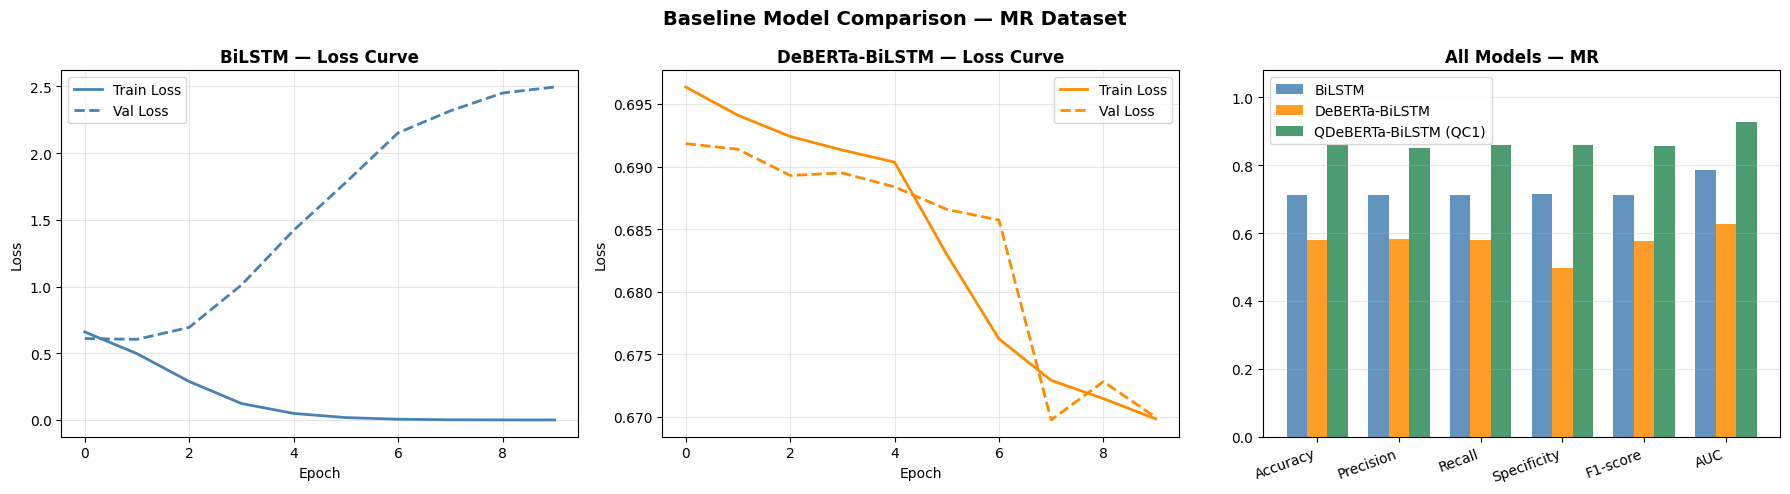


Done. Plot saved as baseline_comparison_MR.png


In [5]:
# ==============================
# 1. Imports
# ==============================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, RandomSampler, SequentialSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score
)
from sklearn.preprocessing import LabelEncoder
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from torch.optim import AdamW
from datasets import load_dataset
import re
import nltk
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
nltk.download('stopwords', quiet=True)

# ✅ FIX CUDA LSTM ERROR
torch.backends.cudnn.enabled = False
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# ==============================
# 2. Config
# ==============================
MAX_LEN    = 128
BATCH_SIZE = 32
EPOCHS     = 10
LR         = 1e-3
HIDDEN_DIM = 128
VOCAB_SIZE  = 128100
EMBED_DIM   = 128
MODEL_NAME  = "microsoft/deberta-v3-base"
DATASET     = "MR"
TEXT_COL    = 'text'
LABEL_COL   = 'label'

# ==============================
# 3. Load & Preprocess Data
# ==============================
ds  = load_dataset("mattymchen/mr")
df  = ds["test"].to_pandas()   # ✅ test split has both classes balanced (5331 each)

print(f"MR dataset loaded: {df.shape}")
print(df.head())
print(f"Label distribution:\n{df[LABEL_COL].value_counts()}")

stop_words = set(stopwords.words('english'))

def clean(text):
    text = str(text)
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = text.lower()
    words = [w for w in text.split() if w not in stop_words]
    return " ".join(words)

df[TEXT_COL] = df[TEXT_COL].apply(clean)
df = df.dropna(subset=[TEXT_COL, LABEL_COL])

le = LabelEncoder()
df[LABEL_COL] = le.fit_transform(df[LABEL_COL])

# Balance classes (already balanced but kept as safety check)
class_counts = df[LABEL_COL].value_counts()
print(f"Before balancing: {class_counts.to_dict()}")

majority = class_counts.idxmax()
minority = class_counts.idxmin()

if class_counts[majority] != class_counts[minority]:
    df_maj = df[df[LABEL_COL] == majority].sample(
        class_counts[minority], random_state=42
    )
    df = pd.concat([df_maj, df[df[LABEL_COL] == minority]]).sample(
        frac=1, random_state=42
    ).reset_index(drop=True)

df = df.sample(frac=1, random_state=42).reset_index(drop=True)
print(f"Balanced dataset: {df[LABEL_COL].value_counts().to_dict()}")

# ==============================
# 4. Split
# ==============================
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df[TEXT_COL], df[LABEL_COL],
    test_size=0.2, stratify=df[LABEL_COL], random_state=42
)
print(f"Train: {len(train_texts)} | Val: {len(val_texts)}")

# ==============================
# 5. Tokenization
# ==============================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def encode(texts):
    return tokenizer(
        texts.tolist(),
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="pt"
    )

train_enc = encode(train_texts)
val_enc   = encode(val_texts)

def make_loader(enc, labels, sampler_cls):
    dataset = TensorDataset(
        enc['input_ids'],
        enc['attention_mask'],
        torch.tensor(labels.values, dtype=torch.long)
    )
    return DataLoader(dataset, sampler=sampler_cls(dataset), batch_size=BATCH_SIZE)

train_loader = make_loader(train_enc, train_labels, RandomSampler)
val_loader   = make_loader(val_enc,   val_labels,   SequentialSampler)

# ==============================
# 6. Metrics Helper
# ==============================
def compute_all_metrics(all_labels, all_preds, all_probs, name):
    all_probs = np.nan_to_num(np.array(all_probs), nan=0.5)

    acc  = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    rec  = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    spec = recall_score(all_labels, all_preds, pos_label=0, average='binary', zero_division=0)
    f1   = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    auc  = roc_auc_score(all_labels, all_probs)

    print(f"\n{'='*55}")
    print(f"  {name} — Final Results ({DATASET})")
    print(f"{'='*55}")
    print(f"  Accuracy    : {acc:.4f}")
    print(f"  Precision   : {prec:.4f}")
    print(f"  Recall      : {rec:.4f}")
    print(f"  Specificity : {spec:.4f}")
    print(f"  F1-score    : {f1:.4f}")
    print(f"  AUC         : {auc:.4f}")
    print(f"\n{classification_report(all_labels, all_preds)}")
    return dict(accuracy=acc, precision=prec, recall=rec,
                specificity=spec, f1=f1, auc=auc)

# ==============================
# 7. Shared Training Loop
# ==============================
def train_and_evaluate(model, train_loader, val_loader, model_name, epochs=EPOCHS, lr=LR):
    model.to(DEVICE)
    trainable   = [p for p in model.parameters() if p.requires_grad]
    optimizer   = AdamW(trainable, lr=lr)
    total_steps = len(train_loader) * epochs
    scheduler   = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=0, num_training_steps=total_steps
    )
    loss_fn = nn.CrossEntropyLoss()
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        # ── Train ──
        model.train()
        t_loss, t_correct, t_total = 0, 0, 0
        for batch in train_loader:
            ids, mask, lbls = [b.to(DEVICE) for b in batch]
            optimizer.zero_grad()
            logits = model(ids, mask)
            loss   = loss_fn(logits, lbls)

            if torch.isnan(loss):
                print("  ⚠️  NaN loss — skipping batch")
                continue

            loss.backward()
            nn.utils.clip_grad_norm_(trainable, 1.0)
            optimizer.step()
            scheduler.step()
            t_loss    += loss.item()
            t_correct += (logits.argmax(1) == lbls).sum().item()
            t_total   += lbls.size(0)

        # ── Validate ──
        model.eval()
        v_loss, v_correct, v_total = 0, 0, 0
        all_preds, all_labels, all_probs = [], [], []

        with torch.no_grad():
            for batch in val_loader:
                ids, mask, lbls = [b.to(DEVICE) for b in batch]
                logits = model(ids, mask)
                loss   = loss_fn(logits, lbls)
                probs  = F.softmax(logits, dim=1)[:, 1].cpu().float().numpy()
                preds  = logits.argmax(1).cpu().numpy()

                v_loss    += loss.item() if not torch.isnan(loss) else 0
                v_correct += (logits.argmax(1) == lbls).sum().item()
                v_total   += lbls.size(0)
                all_preds.extend(preds)
                all_labels.extend(lbls.cpu().numpy())
                all_probs.extend(probs)

        avg_t = t_loss / max(len(train_loader), 1)
        avg_v = v_loss / max(len(val_loader), 1)
        v_acc = v_correct / max(v_total, 1)
        history['train_loss'].append(avg_t)
        history['val_loss'].append(avg_v)
        history['val_acc'].append(v_acc)

        print(f"[{model_name}] Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {avg_t:.4f} | Val Loss: {avg_v:.4f} | Val Acc: {v_acc:.4f}")

    metrics = compute_all_metrics(
        np.array(all_labels), np.array(all_preds), np.array(all_probs), model_name
    )
    return history, metrics

# ==============================
# 8. MODEL A — Plain BiLSTM
# ==============================
class BiLSTMOnly(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(VOCAB_SIZE, EMBED_DIM, padding_idx=0)
        self.lstm = nn.LSTM(
            input_size=EMBED_DIM,
            hidden_size=HIDDEN_DIM,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )
        self.dropout = nn.Dropout(0.3)
        self.fc      = nn.Linear(HIDDEN_DIM * 2, 2)

    def forward(self, ids, mask):
        x = self.embedding(ids).float()
        x = x * mask.unsqueeze(-1).float()
        lstm_out, _ = self.lstm(x)
        mask_exp = mask.unsqueeze(-1).float()
        pooled   = (lstm_out * mask_exp).sum(1) / mask_exp.sum(1).clamp(min=1e-9)
        return self.fc(self.dropout(pooled))

# ==============================
# 9. MODEL B — DeBERTa-BiLSTM (frozen encoder)
# ==============================
class DebertaBiLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert = AutoModel.from_pretrained(MODEL_NAME)
        for param in self.bert.parameters():
            param.requires_grad = False         # ✅ freeze encoder

        self.lstm = nn.LSTM(
            input_size=768,
            hidden_size=HIDDEN_DIM,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )
        self.dropout = nn.Dropout(0.3)
        self.fc      = nn.Linear(HIDDEN_DIM * 2, 2)

    def forward(self, ids, mask):
        with torch.no_grad():
            outputs = self.bert(input_ids=ids, attention_mask=mask)
        x = outputs.last_hidden_state.detach().float()  # ✅ float32 cast
        lstm_out, _ = self.lstm(x)
        mask_exp = mask.unsqueeze(-1).float()
        pooled   = (lstm_out * mask_exp).sum(1) / mask_exp.sum(1).clamp(min=1e-9)
        return self.fc(self.dropout(pooled))

# ==============================
# 10. Run MODEL A — BiLSTM
# ==============================
print("\n" + "="*55)
print(f"MODEL A: BiLSTM — {DATASET}")
print("="*55)
bilstm_model = BiLSTMOnly()
history_a, metrics_a = train_and_evaluate(
    bilstm_model, train_loader, val_loader, "BiLSTM", lr=1e-3
)

# ==============================
# 11. Run MODEL B — DeBERTa-BiLSTM
# ==============================
print("\n" + "="*55)
print(f"MODEL B: DeBERTa-BiLSTM — {DATASET}")
print("="*55)
deberta_bilstm = DebertaBiLSTM()
history_b, metrics_b = train_and_evaluate(
    deberta_bilstm, train_loader, val_loader, "DeBERTa-BiLSTM", lr=1e-3
)

# ==============================
# 12. Comparison Table
# ✅ QDeBERTa-BiLSTM values = MR QC1 results from your paper
# ==============================
print("\n" + "="*55)
print(f"FINAL COMPARISON TABLE — {DATASET}")
print("="*55)

keys       = ['accuracy', 'precision', 'recall', 'specificity', 'f1', 'auc']
labels_row = ['Accuracy', 'Precision', 'Recall', 'Specificity', 'F1-score', 'AUC']

comparison = pd.DataFrame({
    'Metric'          : labels_row,
    'BiLSTM'          : [round(metrics_a[k], 4) for k in keys],
    'DeBERTa-BiLSTM'  : [round(metrics_b[k], 4) for k in keys],
    'QDeBERTa-BiLSTM' : [0.8594, 0.8523, 0.8589, 0.8597, 0.8556, 0.9271],
}).set_index('Metric')

print(comparison.to_string())

# ==============================
# 13. Plots
# ==============================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Baseline Model Comparison — {DATASET} Dataset",
             fontsize=14, fontweight='bold')

axes[0].plot(history_a['train_loss'], label='Train Loss', color='steelblue', linewidth=2)
axes[0].plot(history_a['val_loss'],   label='Val Loss',   color='steelblue', linewidth=2, linestyle='--')
axes[0].set_title("BiLSTM — Loss Curve", fontweight='bold')
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history_b['train_loss'], label='Train Loss', color='darkorange', linewidth=2)
axes[1].plot(history_b['val_loss'],   label='Val Loss',   color='darkorange', linewidth=2, linestyle='--')
axes[1].set_title("DeBERTa-BiLSTM — Loss Curve", fontweight='bold')
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].legend(); axes[1].grid(alpha=0.3)

x = np.arange(len(labels_row))
w = 0.25
axes[2].bar(x - w, [metrics_a[k] for k in keys], w,
            label='BiLSTM', color='steelblue', alpha=0.85)
axes[2].bar(x,     [metrics_b[k] for k in keys], w,
            label='DeBERTa-BiLSTM', color='darkorange', alpha=0.85)
axes[2].bar(x + w, [0.8594, 0.8523, 0.8589, 0.8597, 0.8556, 0.9271], w,
            label='QDeBERTa-BiLSTM (QC1)', color='seagreen', alpha=0.85)
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels_row, rotation=20, ha='right')
axes[2].set_ylim(0, 1.08)
axes[2].set_title(f"All Models — {DATASET}", fontweight='bold')
axes[2].legend(); axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f"baseline_comparison_{DATASET}.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"\nDone. Plot saved as baseline_comparison_{DATASET}.png")

In [4]:
ds = load_dataset("mattymchen/mr")
df = ds["test"].to_pandas()   # ✅ use test split only

print(f"MR dataset loaded: {df.shape}")
print(df.head())
print(f"Label distribution:\n{df['label'].value_counts()}")

# Balance classes
class_counts = df[LABEL_COL].value_counts()
print(f"Before balancing: {class_counts.to_dict()}")

majority = class_counts.idxmax()
minority = class_counts.idxmin()

if class_counts[majority] != class_counts[minority]:
    df_maj = df[df[LABEL_COL] == majority].sample(
        class_counts[minority], random_state=42
    )
    df = pd.concat([df_maj, df[df[LABEL_COL] == minority]]).sample(
        frac=1, random_state=42
    ).reset_index(drop=True)

print(f"Balanced dataset: {df[LABEL_COL].value_counts().to_dict()}")

MR dataset loaded: (10662, 2)
                                                text  label
0  with its dogged hollywood naturalism and the i...      0
1  . . . has its moments , but ultimately , its c...      0
2  leigh 's film is full of memorable performance...      1
3  the code talkers deserved better than a hollow...      0
4     i have to admit that i am baffled by jason x .      0
Label distribution:
label
0    5331
1    5331
Name: count, dtype: int64
Before balancing: {0: 5331, 1: 5331}
Balanced dataset: {0: 5331, 1: 5331}
